In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.arima.model import ARIMA

In [ ]:
api_key = "5326f043daec4329a7041b579b9aaa53"

params = {
    "symbol": "AAPL",
    "interval": "1day",
    "outputsize": "100",
    "apikey": api_key
}

url = "https://api.twelvedata.com/time_series"
data = requests.get(url, params=params).json()

df = pd.DataFrame(data["values"])

In [ ]:
df.drop(columns = ["high", "low", "close", "volume"], inplace=True)

In [ ]:
df

,datetime,open
0,2025-04-08,186.73000
1,2025-04-07,177.20000
2,2025-04-04,193.89000
3,2025-04-03,205.53999
4,2025-04-02,221.32001
...,...,...
95,2024-11-18,225.25
96,2024-11-15,226.39999
97,2024-11-14,225.020004
98,2024-11-13,224.0099945


In [ ]:
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index("datetime", inplace=True)

In [ ]:
ts = df['open']
ts = ts.astype(float)

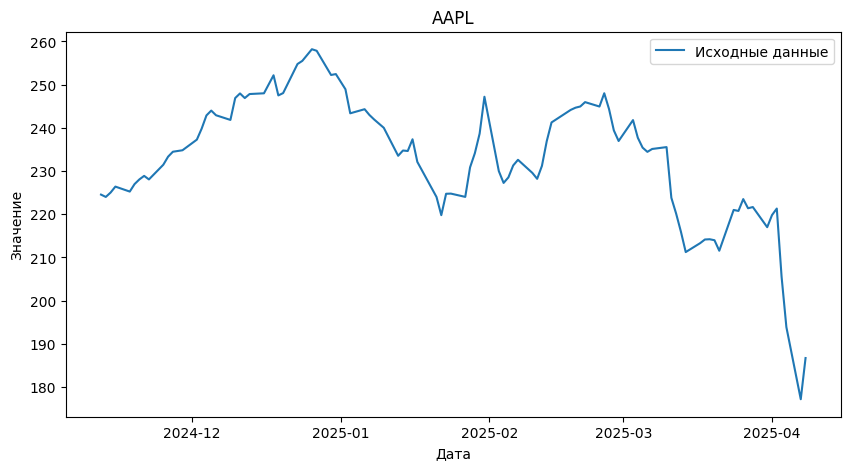

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(ts, label="Исходные данные")
plt.title("AAPL")
plt.xlabel("Дата")
plt.ylabel("Значение")
plt.legend()
plt.show()

In [ ]:
model = ARIMA(ts[:-10], order=(1, 1, 1))
result = model.fit()

print(result.summary())

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsm

                               SARIMAX Results                                
Dep. Variable:                   open   No. Observations:                  100
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -292.115
Date:                Tue, 08 Apr 2025   AIC                            590.230
Time:                        22:15:51   BIC                            598.015
Sample:                             0   HQIC                           593.380
                                - 100                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0864      0.478      0.181      0.857      -0.851       1.024
ma.L1          0.0721      0.500      0.144      0.885      -0.908       1.052
sigma2        21.3953      1.887     11.339      0.0

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


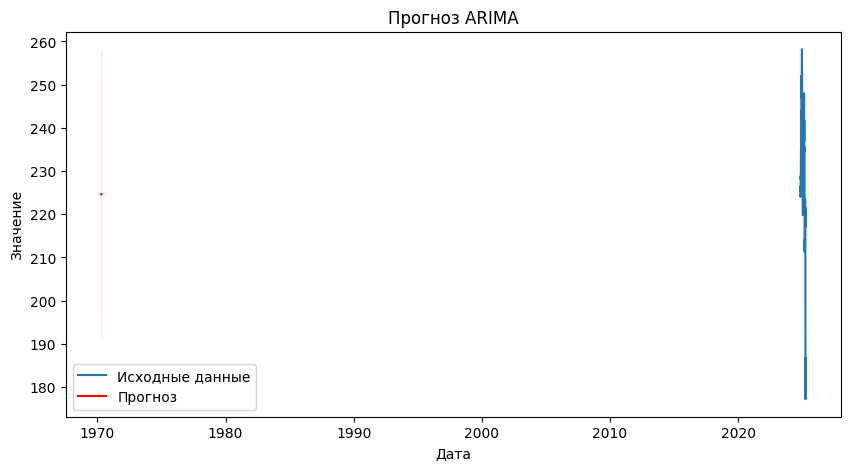

In [ ]:
# Прогноз на 10 шагов вперед
forecast_steps = 10
forecast = result.get_forecast(steps=forecast_steps)
forecast_mean = forecast.predicted_mean
confidence_interval = forecast.conf_int()

# Визуализация
plt.figure(figsize=(10, 5))
plt.plot(ts, label="Исходные данные")
plt.plot(forecast_mean, label="Прогноз", color="red")
plt.fill_between(
    confidence_interval.index,
    confidence_interval.iloc[:, 0],
    confidence_interval.iloc[:, 1],
    color="pink",
    alpha=0.3,
)
plt.title("Прогноз ARIMA")
plt.xlabel("Дата")
plt.ylabel("Значение")
plt.legend()
plt.show()

In [ ]:
#Вычисление MAE
actual_values = ts.values[-forecast_steps:]
predicted_values = forecast_mean.values

mae = np.mean(np.abs(predicted_values - actual_values))
print(f"Средняя абсолютная ошибка (MAE): {mae:.2f}")

Средняя абсолютная ошибка (MAE): 2.36
